# Level 1: Scientific Problem Framing and Python Foundation

**Project:** HydroSense-Kenya  
**Level:** 1 of 6

---

## Project Overview

HydroSense-Kenya is a smart irrigation decision-support system designed to improve water-use efficiency for smallholder farmers. The system aims to combine elements like; ***Weather observations, Soil sensor measurements, and Crop-specific moisture requirements*** to determine when irrigation should occur and how much water should be applied.

The project serves as a practical application of Scientific Computing concepts including: ***Data preprocessing, Numerical methods,Simulation modelling, Optimization, and Error analysis***

---

### Main Goal

Use scientific computing techniques to minimize water wastage while maintaining healthy soil moisture levels for crop growth. 

---

## 1. Scientific Context

Agriculture contributes significantly to Kenya's economy and food security. However, irrigation decisions are often based on experience rather than quantitative analysis. This can lead to:

- Over-irrigation
- Under-irrigation
- Water wastage
- Reduced crop yields

HydroSense-Kenya addresses this challenge by using environmental measurements and mathematical models to support irrigation decisions.


### Scientific Questions

This project seeks to answer:

1. How much water is currently available in the soil?
2. How much water will be lost through evapotranspiration?
3. How much rainfall is expected?
4. When should irrigation occur?
5. How much irrigation is required?

---

## 2. Import Required Libraries

The following libraries are used throughout the project:

| Library | Purpose |
|----------|----------|
| Pandas | Data handling |
| NumPy | Numerical computation |
| Matplotlib | Visualization |
| Pathlib | File handling |

These libraries form the foundation for the later numerical and simulation tasks.

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

The above will help us read from the `src/` folder. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Libraries loaded successfully")
print(f"Pandas Version : {pd.__version__}")
print(f"NumPy Version  : {np.__version__}")

Libraries loaded successfully
Pandas Version : 2.3.2
NumPy Version  : 2.2.5


## 3. Load the Datasets

HydroSense-Kenya uses three datasets.


In [3]:
weather = pd.read_csv(
    "../data/processed/weather_daily_cleaned.csv"
)

soil = pd.read_csv(
    "../data/processed/soil_sensor_data_cleaned.csv"
)

params = pd.read_csv(
    "../data/processed/crop_zone_parameters_cleaned.csv"
)

print("Datasets loaded successfully")

Datasets loaded successfully


### Weather Dataset

Contains daily environmental observations:

- Rainfall
- Temperature
- Humidity
- Wind speed
- Solar radiation index


In [4]:
print("WEATHER DATASET")
print(weather.head())

print("\nShape:", weather.shape)

WEATHER DATASET
         date  rainfall_mm  temperature_c  humidity_pct  wind_speed_mps  \
0  2026-03-01          3.2           23.8          69.7            2.28   
1  2026-03-02          2.2           25.9          62.0            1.62   
2  2026-03-03          3.0           26.8          64.4            2.11   
3  2026-03-04          1.6           27.0          64.6            2.09   
4  2026-03-05         23.7           26.6          61.0            1.36   

   solar_index  
0         0.78  
1         0.71  
2         0.75  
3         0.58  
4         0.62  

Shape: (28, 6)


---
---

### Soil Sensor Dataset

Contains field measurements:

- Soil moisture
- Tank level
- Pump flow
- Pump power


In [5]:
print("SOIL SENSOR DATASET")
print(soil.head())

print("\nShape:", soil.shape)

SOIL SENSOR DATASET
             timestamp zone_id  soil_moisture_pct  tank_level_liters  \
0  2026-03-01 12:00:00  Zone_A               33.2               4829   
1  2026-03-01 12:00:00  Zone_B               34.7               4728   
2  2026-03-01 12:00:00  Zone_C               28.2               4515   
3  2026-03-02 12:00:00  Zone_A               36.1               4757   
4  2026-03-02 12:00:00  Zone_B               32.0               4645   

   pump_flow_lpm  pump_power_watts sensor_status  
0           18.8               437            OK  
1           22.1               461            OK  
2           25.7               490            OK  
3           16.6               411            OK  
4           20.4               445            OK  

Shape: (89, 7)


---
---

### Crop Zone Parameters

Contains static characteristics of each irrigation zone:

- Field capacity
- Target moisture
- Minimum moisture
- Drainage coefficient

In [6]:
print("CROP PARAMETERS")
print(params)

print("\nShape:", params.shape)

CROP PARAMETERS
  zone_id crop_type  area_m2  min_moisture_pct  target_moisture_pct  \
0  Zone_A    tomato      120                22                   33   
1  Zone_B      kale       90                24                   35   
2  Zone_C     maize      180                20                   31   

   field_capacity_pct  drainage_coefficient  
0                  41                  0.18  
1                  43                  0.15  
2                  40                  0.22  

Shape: (3, 7)


## 4. Data Dictionary

Understanding the meaning of each variable at play affecting the crops [and the numerical units they are represented in] is critical before performing any scientific analysis. They are;

### Weather Variables

| Variable | Unit | Description |
|-----------|--------|-------------|
| rainfall_mm | mm | Daily rainfall |
| temperature_c | °C | Air temperature |
| humidity_pct | % | Relative humidity |
| wind_speed_mps | m/s | Wind speed |
| solar_index | 0–1 | Solar radiation indicator |

---

### Soil Variables

| Variable | Unit |
|-----------|--------|
| soil_moisture_pct | % |
| tank_level_liters | L |
| pump_flow_lpm | L/min |
| pump_power_watts | W |

---
---

## 5. Water Balance Principle

The HydroSense simulator is based on a water balance model.

The fundamental idea is:

$$
\text{New Moisture}
=
\text{Current Moisture}
+
\text{Rainfall}
+
\text{Irrigation}
-
\text{Evapotranspiration}
-
\text{Drainage}
\
$$

This equation conserves water and forms the foundation of the simulation model used in later levels.

In [7]:
from src.simulation import calculate_et

sample_et = calculate_et(
    temperature=24,
    wind_speed=3,
    solar_index=0.8,
    humidity=70
)

print(f"Estimated ET = {sample_et:.3f} mm/day")

Estimated ET = 4.100 mm/day


## 6. Evapotranspiration (ET)

Evapotranspiration represents water loss from *Soil evaporation* and *Plant transpiration*. Higher values typically occur when (**Temperature increases, Wind speed increases, and Solar radiation increases**). Lower values occur when **Humidity increases**. 

HydroSense uses ET to estimate future moisture loss.

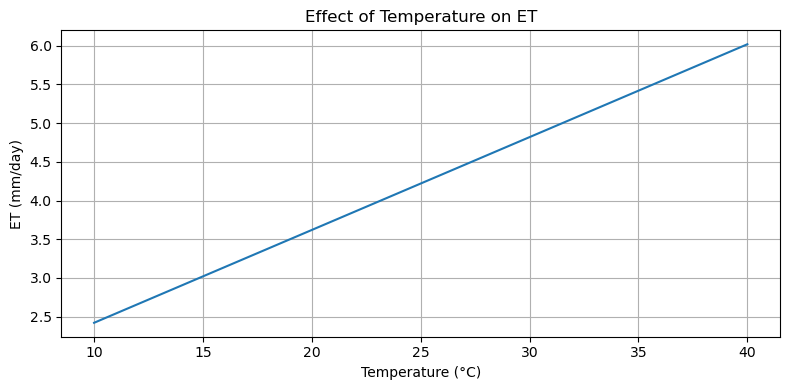

In [8]:
temps = np.arange(10, 41)

et_values = [
    calculate_et(
        temperature=t,
        wind_speed=3,
        solar_index=0.8,
        humidity=70
    )
    for t in temps
]

plt.figure(figsize=(8,4))
plt.plot(temps, et_values)
plt.xlabel("Temperature (°C)")
plt.ylabel("ET (mm/day)")
plt.title("Effect of Temperature on ET")
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation

The graph shows a positive relationship between temperature and evapotranspiration.

As temperature increases, more water is lost from the soil-plant system.

This observation highlights why irrigation scheduling becomes more important during hotter periods.

In [9]:
weather.describe()

,rainfall_mm,temperature_c,humidity_pct,wind_speed_mps,solar_index
count,28.000000,28.000000,28.000000,28.000000,28.000000
mean,8.851108,24.560714,65.678571,2.091786,0.675357
std,16.590793,1.856388,4.159270,0.527573,0.095897
min,0.000000,21.400000,56.300000,1.140000,0.490000
25%,0.850000,22.950000,63.475000,1.642500,0.587500
50%,3.100000,24.700000,64.850000,2.115000,0.695000
75%,8.573276,26.375000,68.375000,2.417500,0.760000
max,85.000000,27.400000,74.600000,3.100000,0.800000


## 7. Initial Observations

From the cleaned datasets:

- Weather measurements fall within realistic Kenyan climate ranges.
- Soil moisture varies across irrigation zones.
- Crop zones have different moisture requirements.
- Environmental conditions change daily.

These observations justify the need for numerical modelling and optimization techniques.

# Conclusion

This notebook has introduced the HydroSense-Kenya project and the datasets used throughout the study. 

Key outcomes are; 

- The problem domain was established. 
- The datasets were loaded and inspected. 
- The water balance concept was introduced. 
- Evapotranspiration was demonstrated. 
- Initial exploratory analysis was performed. 